# LSTM Price Forecasting Model Training

This notebook loads recent 5 years of daily wholesale market price data (from 2021 to 2025) from raw Agmarknet CSVs, aggregates it to monthly average modal prices per Ton in INR, and trains an LSTM model to forecast future prices for all 22 supported crops using real-world historical records.

In [2]:
import numpy as np
import pandas as pd
import json
import os
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

## 1. Load and Clean Real Historical Data

We load the raw Agmarknet CSV files (2021 to 2025) and filter them for the 22 supported crops. The prices are aggregated as monthly averages in INR/Ton.

In [3]:
# Years to load (recent 5 years: 2021 to 2025)
years = [2021, 2022, 2023, 2024, 2025]

# Determine the directory path containing raw CSV files
csv_dir = '../data/csv' if os.path.exists('../data/csv') else 'ml/data/csv'

csv_files = []
for y in years:
    p = os.path.join(csv_dir, f'{y}.csv')
    if os.path.exists(p):
        csv_files.append(p)

print('Found files:', csv_files)

# Base prices in INR/Ton for all 22 supported crops (used for metadata/grounding references)
base_prices = {
    'rice': 23000, 'maize': 22250, 'chickpea': 54400, 'kidneybeans': 75000,
    'pigeonpeas': 70000, 'mothbeans': 60000, 'mungbean': 85580, 'blackgram': 69500,
    'lentil': 64250, 'pomegranate': 80000, 'banana': 15000, 'mango': 40000,
    'grapes': 60000, 'watermelon': 10000, 'muskmelon': 15000, 'apple': 100000,
    'orange': 35000, 'papaya': 20000, 'coconut': 25000, 'cotton': 75000,
    'jute': 55000, 'coffee': 250000
}

# Mapping dataset commodity names to supported crop keys
crop_mapping = {
    'rice': 'Rice',
    'maize': 'Maize',
    'chickpea': 'Bengal Gram (Gram)(Whole)',
    'kidneybeans': 'Rajgir',
    'pigeonpeas': 'Arhar (Tur/Red Gram)(Whole)',
    'mothbeans': 'Mataki',
    'mungbean': 'Green Gram (Moong)(Whole)',
    'blackgram': 'Black Gram (Urd Beans)(Whole)',
    'lentil': 'Lentil (Masur)(Whole)',
    'pomegranate': 'Pomegranate',
    'banana': 'Banana',
    'mango': 'Mango',
    'grapes': 'Grapes',
    'watermelon': 'Water Melon',
    'muskmelon': 'Karbuja (Musk Melon)',
    'apple': 'Apple',
    'orange': 'Orange',
    'papaya': 'Papaya',
    'coconut': 'Coconut',
    'cotton': 'Cotton',
    'jute': 'Jute',
    'coffee': 'Coffee'
}

data_list = []
for file_path in csv_files:
    print(f'Reading {file_path}...')
    # Read only required columns to be memory efficient
    chunk_df = pd.read_csv(file_path, usecols=['Arrival_Date', 'Commodity', 'Modal_Price'])
    # Filter for the crops that exist in our mapping
    chunk_df = chunk_df[chunk_df['Commodity'].isin(crop_mapping.values())]
    data_list.append(chunk_df)

df_raw = pd.concat(data_list, ignore_index=True)

# Preprocess and aggregate
df_raw['date'] = pd.to_datetime(df_raw['Arrival_Date'], errors='coerce')
df_raw = df_raw.dropna(subset=['date'])
df_raw['month'] = df_raw['date'].dt.to_period('M')

# Reverse map commodity back to crop key
reverse_map = {v: k for k, v in crop_mapping.items()}
df_raw['crop'] = df_raw['Commodity'].map(reverse_map)

# Convert Modal_Price to float and multiply by 10 to convert from INR/Quintal to INR/Ton
df_raw['price_ton'] = pd.to_numeric(df_raw['Modal_Price'], errors='coerce') * 10
df_raw = df_raw.dropna(subset=['price_ton'])

# Group by crop and month to average monthly price per Ton
df_monthly = df_raw.groupby(['crop', 'month'])['price_ton'].mean().reset_index()

months = 60 # 5 years
seq_length = 5

data = []
crop_history_dict = {}

for crop in base_prices.keys():
    crop_df = df_monthly[df_monthly['crop'] == crop].copy()
    crop_df = crop_df.sort_values(by='month', ascending=True)
    prices = crop_df['price_ton'].tolist()
    actual_months = len(prices)
    print(f'Loaded {actual_months} real records for {crop}')
        
    crop_history_dict[crop] = prices[-seq_length:]
    
    for i in range(actual_months):
        data.append({
            'crop': crop,
            'month_idx': i,
            'price': prices[i]
        })

df = pd.DataFrame(data)

print('\nSample of combined data:')
print(df.head(10))

Found files: ['../data/csv\\2021.csv', '../data/csv\\2022.csv', '../data/csv\\2023.csv', '../data/csv\\2024.csv', '../data/csv\\2025.csv']
Reading ../data/csv\2021.csv...
Reading ../data/csv\2022.csv...
Reading ../data/csv\2023.csv...
Reading ../data/csv\2024.csv...
Reading ../data/csv\2025.csv...
Loaded 60 real records for rice
Loaded 60 real records for maize
Loaded 60 real records for chickpea
Loaded 60 real records for kidneybeans
Loaded 60 real records for pigeonpeas
Loaded 60 real records for mothbeans
Loaded 60 real records for mungbean
Loaded 60 real records for blackgram
Loaded 60 real records for lentil
Loaded 60 real records for pomegranate
Loaded 60 real records for banana
Loaded 60 real records for mango
Loaded 60 real records for grapes
Loaded 60 real records for watermelon
Loaded 60 real records for muskmelon
Loaded 60 real records for apple
Loaded 60 real records for orange
Loaded 60 real records for papaya
Loaded 60 real records for coconut
Loaded 60 real records for c

## 2. Prepare Data for LSTM (Sequence Formatting & Scaling)

We'll scale all prices across the board using a single `MinMaxScaler`.

In [4]:
scaler = MinMaxScaler()
df['scaled_price'] = scaler.fit_transform(df[['price']])

X, y = [], []

# Build sequences per crop
for crop in df['crop'].unique():
    crop_data = df[df['crop'] == crop]['scaled_price'].values
    for i in range(len(crop_data) - seq_length):
        X.append(crop_data[i : i + seq_length])
        y.append(crop_data[i + seq_length])

X = np.array(X)
y = np.array(y)

# Reshape X for LSTM [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1210, 5, 1)
y shape: (1210,)


## 3. Build & Train the LSTM Model

In [5]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

history = model.fit(X, y, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

c:\Users\ronad\OneDrive\Desktop\Projects\WEB + ML\AgriMindAI\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0071 - val_loss: 0.0071
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014 - val_loss: 0.0029
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0013 - val_loss: 0.0035
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0012 - val_loss: 0.0034
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0012 - val_loss: 0.0038
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011 - val_loss: 0.0028
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 0.0038
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0010 - val_loss: 0.0032
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0010 - val_loss: 0.0036
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1456e-04 - val_loss: 0.0046
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/

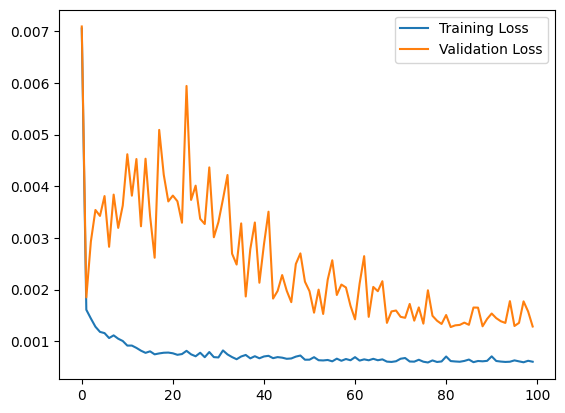

In [6]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

## 4. Export the artifacts

In [7]:
MODELS_DIR = '../ml/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Save the model weights/architecture
model.save(os.path.join(MODELS_DIR, 'lstm_price_model.h5'))

# Save the scaler
joblib.dump(scaler, os.path.join(MODELS_DIR, 'price_scaler.pkl'))

# Save the historical price dictionary (used to form the sequence at runtime)
with open(os.path.join(MODELS_DIR, 'crop_price_history.json'), 'w') as f:
    json.dump(crop_history_dict, f)

print("✅ All ML Artifacts successfully saved to ml/models/")

✅ All ML Artifacts successfully saved to ml/models/
